In [ ]:
#import bibliotek
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#podłączenie dysku google
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#tworzenie data frame
products = pd.read_csv('/content/drive/MyDrive/Olist_dane/olist_products_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/Olist_dane/olist_order_items_dataset.csv')
order_reviews = pd.read_csv('/content/drive/MyDrive/Olist_dane/olist_order_reviews_dataset.csv')

In [ ]:
#przegląd danych - products
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
#sprawdzenie wartości pustych
products.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
products[products.isna().any(axis=1)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [ ]:
#usunięcie wszystkich wierszy z pustymi wartościami
products = products.dropna()

In [ ]:
#sprawdzenie czy wszystkie wartości dla product_id są unikalne
products['product_id'].is_unique

True

In [ ]:
#przegląd danych - order_items
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [ ]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
#sprawdzenie wartości pustych
order_items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [ ]:
#sprawdzenie czy kolumna order_id ma duplikaty
order_items['order_id'].is_unique

False

In [ ]:
#sprawdzenie jakie duplikaty występują
order_items[order_items.duplicated(subset = ['order_id'], keep = False)]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
...,...,...,...,...,...,...,...
112635,fff8287bbae429a99bb7e8c21d151c41,2,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14
112640,fffb9224b6fc7c43ebb0904318b10b5f,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19


In [ ]:
#przegląd danych - order_review
order_reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
order_reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
#sprawdzenie czy są wartości puste
order_reviews.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
#sprawdzenie czy kolumna review_id ma duplikaty
order_reviews['review_id'].is_unique

False

In [ ]:
#sprawdzenie ile duplikatów ma kolumna review_id
order_reviews['review_id'].duplicated().sum()

np.int64(814)

In [ ]:

order_reviews[order_reviews.duplicated(subset=["review_id"], keep=False)].sort_values("review_id").head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,NaN,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07 00:00:00,2018-03-20 18:08:23
90677,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,NaN,NaN,2017-09-21 00:00:00,2017-09-26 03:27:47
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
54832,017808d29fd1f942d97e50184dfb4c13,8daaa9e99d60fbba579cc1c3e3bfae01,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30
20621,0254bd905dc677a6078990aad3331a36,5bf226cf882c5bf4247f89a97c86f273,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44
96080,0254bd905dc677a6078990aad3331a36,331b367bdd766f3d1cf518777317b5d9,1,NaN,O pedido consta de 2 produtos e até agora rece...,2017-09-09 00:00:00,2017-09-13 09:52:44


In [ ]:
#usunięcie duplikatów opinii
order_reviews = order_reviews.drop_duplicates(subset=["review_id"], keep="last")

In [ ]:
#sprawdzenie czy kolumna order_id ma duplikaty
order_reviews['order_id'].is_unique

False

In [ ]:
#sprawdzenie jakie kolumna order_id ma duplikaty
order_reviews[order_reviews["order_id"].duplicated(keep=False)].sort_values("order_id")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
...,...,...,...,...,...,...,...
80631,c509f8b367ee5227700c29fcc76a097a,fd95ae805c63c534f1a64589e102225e,5,NaN,"Recebi dentro do prazo estabelecido, produtos ...",2018-03-04 00:00:00,2018-03-06 10:10:08
9898,117b4a19af2b247561f0075f73d6eea1,fe041ba1c9f54016432fa6ee91709dbc,5,NaN,NaN,2017-12-20 00:00:00,2017-12-20 22:04:37
42177,9da0796858da97acd8b67578388a3241,fe041ba1c9f54016432fa6ee91709dbc,5,NaN,"O cartucho está estourado (vazando), já contat...",2017-12-20 00:00:00,2017-12-20 22:03:18
41355,39de8ad3a1a494fc68cc2d5382f052f4,ff850ba359507b996e8b2fbb26df8d03,5,NaN,Envio rapido... Produto 100%,2017-08-16 00:00:00,2017-08-17 11:56:55


In [ ]:
#usunięcie duplikatów, pozostawiono ostatnią opinię (są to akutalizacje tej samej opinii)
order_reviews = order_reviews.drop_duplicates(subset=["order_id"], keep="last")

In [ ]:
#łączenie tabel - każdy item ma cechy produktu
items_products = order_items[['order_id', 'product_id']].merge(products[['product_id', 'product_description_lenght', 'product_photos_qty']], on='product_id')

In [ ]:
items_products.head(10)

,order_id,product_id,product_description_lenght,product_photos_qty
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,598.0,4.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.0,2.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,695.0,2.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,480.0,1.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,409.0,1.0
5,00048cc3ae777c65dbb7d2a0634bc1ea,ef92defde845ab8450f9d70c526ef70f,558.0,1.0
6,00054e8431b9d7675808bcb819fb4a32,8d4f2bb7e93e6710a28f34fa83ee7d28,815.0,1.0
7,000576fe39319847cbb9d288c5617fa6,557d850972a7d6f792fd18ae1400d9b6,1310.0,3.0
8,0005a1a1728c9d785b8e2b08b904576c,310ae3c140ff94b03219ad0adc3c778f,493.0,1.0
9,0005f50442cb953dcd1d21e1fb923495,4535b0e1091c278dfd193e5a1d63b39f,1192.0,1.0


In [ ]:
#łączenie 2 - każdy item ma opinię
items_product_reviews = items_products.merge(order_reviews[['order_id', 'review_score']], on='order_id')

In [ ]:
items_product_reviews.head(20)

,order_id,product_id,product_description_lenght,product_photos_qty,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,598.0,4.0,5
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.0,2.0,4
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,695.0,2.0,5
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,480.0,1.0,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,409.0,1.0,5
5,00048cc3ae777c65dbb7d2a0634bc1ea,ef92defde845ab8450f9d70c526ef70f,558.0,1.0,4
6,00054e8431b9d7675808bcb819fb4a32,8d4f2bb7e93e6710a28f34fa83ee7d28,815.0,1.0,4
7,000576fe39319847cbb9d288c5617fa6,557d850972a7d6f792fd18ae1400d9b6,1310.0,3.0,5
8,0005a1a1728c9d785b8e2b08b904576c,310ae3c140ff94b03219ad0adc3c778f,493.0,1.0,1
9,0005f50442cb953dcd1d21e1fb923495,4535b0e1091c278dfd193e5a1d63b39f,1192.0,1.0,4


In [ ]:
#zamówienie w którym jest więcej niż jeden produkt, jedno zamówienie: średnią ilość zdjęć i średnią długość opisu produktów w zamówieniu oraz jego ocena
orders_features = items_product_reviews.groupby("order_id").agg(
    product_photos_qty = ('product_photos_qty', "mean"),
    product_description_lenght = ("product_description_lenght", "mean"),
    review_score = ("review_score", "first")
).reset_index()

In [ ]:
orders_features.head(20)

,order_id,product_photos_qty,product_description_lenght,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4.0,598.0,5
1,00018f77f2f0320c557190d7a144bdd3,2.0,239.0,4
2,000229ec398224ef6ca0657da4fc703e,2.0,695.0,5
3,00024acbcdf0a6daa1e931b038114c75,1.0,480.0,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,409.0,5
5,00048cc3ae777c65dbb7d2a0634bc1ea,1.0,558.0,4
6,00054e8431b9d7675808bcb819fb4a32,1.0,815.0,4
7,000576fe39319847cbb9d288c5617fa6,3.0,1310.0,5
8,0005a1a1728c9d785b8e2b08b904576c,1.0,493.0,1
9,0005f50442cb953dcd1d21e1fb923495,1.0,1192.0,4


In [ ]:
#sprawdzenie czy groupby zadziałało prawidłowo
orders_features['order_id'].is_unique

True

/tmp/ipykernel_11265/3683320394.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_score_by_description_bin = orders_features.groupby("desc_bin")["review_score"].mean()


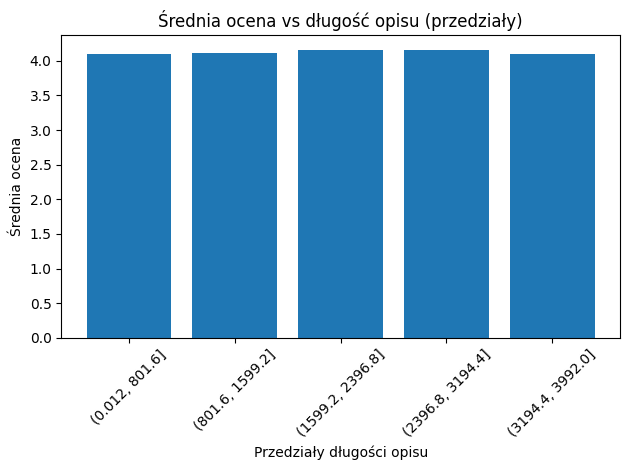

In [ ]:
#wpływ długości opisu na oceny klientów
orders_features["desc_bin"] = pd.cut(
    orders_features["product_description_lenght"],
    bins=5
)

review_score_by_description_bin = orders_features.groupby("desc_bin")["review_score"].mean()

plt.bar(
    review_score_by_description_bin.index.astype(str),
    review_score_by_description_bin.values
)

plt.title("Średnia ocena vs długość opisu (przedziały)")
plt.xlabel("Przedziały długości opisu")
plt.ylabel("Średnia ocena")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
review_score_by_description_bin

,review_score
desc_bin,
"(0.012, 801.6]",4.101886
"(801.6, 1599.2]",4.109480
"(1599.2, 2396.8]",4.160133
"(2396.8, 3194.4]",4.160871
"(3194.4, 3992.0]",4.104355


/tmp/ipykernel_11265/840064370.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  review_score_by_photos_qty_bin = orders_features.groupby("desc_bin")["review_score"].mean()


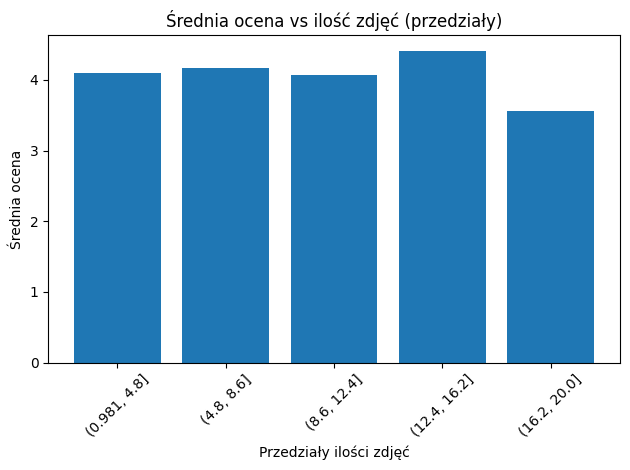

In [ ]:
#wpływ ilości zdjęć na oceny klientów
orders_features["desc_bin"] = pd.cut(
    orders_features["product_photos_qty"],
    bins=5
)

review_score_by_photos_qty_bin = orders_features.groupby("desc_bin")["review_score"].mean()


plt.bar(
    review_score_by_photos_qty_bin.index.astype(str),
    review_score_by_photos_qty_bin.values
)

plt.title("Średnia ocena vs ilość zdjęć (przedziały)")
plt.xlabel("Przedziały ilości zdjęć")
plt.ylabel("Średnia ocena")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
review_score_by_photos_qty_bin

,review_score
desc_bin,
"(0.981, 4.8]",4.102453
"(4.8, 8.6]",4.165178
"(8.6, 12.4]",4.069264
"(12.4, 16.2]",4.409091
"(16.2, 20.0]",3.562500


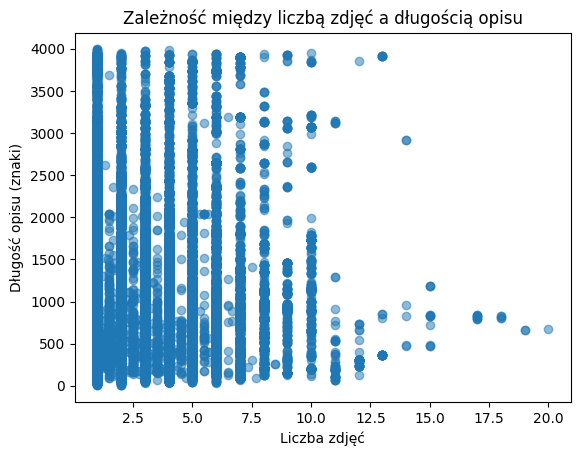

In [ ]:
# zależność między liczbą zdjęć a długością opisu
plt.scatter(
    orders_features["product_photos_qty"],
    orders_features["product_description_lenght"],
    alpha=0.5,
)

plt.title("Zależność między liczbą zdjęć a długością opisu")
plt.xlabel("Liczba zdjęć")
plt.ylabel("Długość opisu (znaki)")

plt.show()

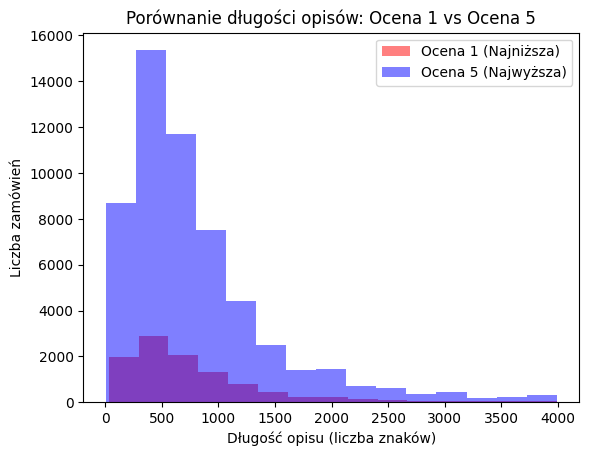

In [ ]:
#porównanie długości opisów dla najlepszej i najgorszej oceny
ocena_1 = orders_features[orders_features["review_score"] == 1]
ocena_5 = orders_features[orders_features["review_score"] == 5]

plt.hist(
    ocena_1["product_description_lenght"],
    bins=15,
    alpha=0.5,
    color="red",
    label="Ocena 1 (Najniższa)",
)
plt.hist(
    ocena_5["product_description_lenght"],
    bins=15,
    alpha=0.5,
    color="blue",
    label="Ocena 5 (Najwyższa)",
)

plt.legend()

plt.title("Porównanie długości opisów: Ocena 1 vs Ocena 5")
plt.xlabel("Długość opisu (liczba znaków)")
plt.ylabel("Liczba zamówień")

plt.show()

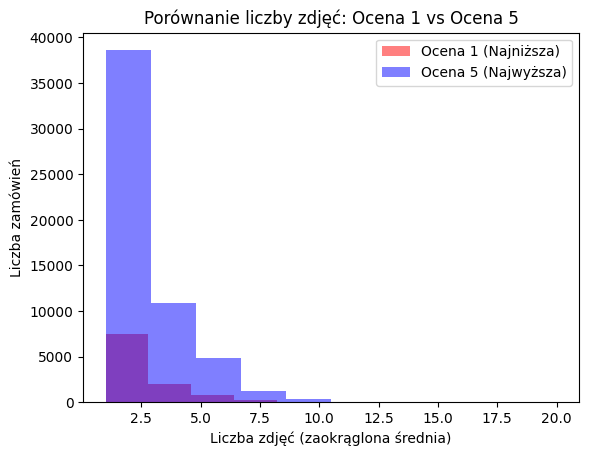

In [ ]:
#porównanie ilości zdjęć dla najlepszej i najgorszej oceny
zdjecia_1 = ocena_1["product_photos_qty"].round()
zdjecia_5 = ocena_5["product_photos_qty"].round()

plt.hist(
    zdjecia_1,
    bins=10,
    alpha=0.5,
    color="red",
    label="Ocena 1 (Najniższa)",
)
plt.hist(
    zdjecia_5,
    bins=10,
    alpha=0.5,
    color="blue",
    label="Ocena 5 (Najwyższa)",
)

plt.legend()

plt.title("Porównanie liczby zdjęć: Ocena 1 vs Ocena 5")
plt.xlabel("Liczba zdjęć (zaokrąglona średnia)")
plt.ylabel("Liczba zamówień")

plt.show()

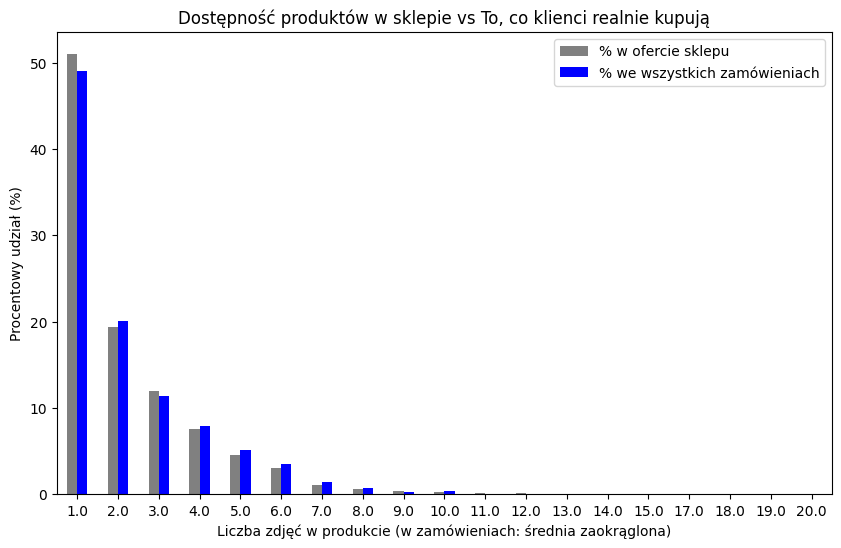

In [ ]:
#dostępność produktów vs to co klienci realnie kupują
oferta_sklepu = (
    products["product_photos_qty"].value_counts(normalize=True).sort_index()
)

zamowienia_zaokraglone = orders_features["product_photos_qty"].round()
realne_zamowienia = (
    zamowienia_zaokraglone.value_counts(normalize=True).sort_index()
)

porownanie = pd.DataFrame(
    {"% w ofercie sklepu": oferta_sklepu, "% we wszystkich zamówieniach": realne_zamowienia}
)

porownanie = porownanie * 100

porownanie.plot(kind="bar", figsize=(10, 6), color=["gray", "blue"], rot=0)

plt.title("Dostępność produktów w sklepie vs To, co klienci realnie kupują")
plt.xlabel("Liczba zdjęć w produkcie (w zamówieniach: średnia zaokrąglona)")
plt.ylabel("Procentowy udział (%)")

plt.show()

In [ ]:
oferta_sklepu

,proportion
product_photos_qty,
1.0,0.509864
2.0,0.193661
3.0,0.119326
4.0,0.075077
5.0,0.045887
6.0,0.029932
7.0,0.010606
8.0,0.005937
9.0,0.003247


In [ ]:
realne_zamowienia

,proportion
product_photos_qty,
1.0,0.490118
2.0,0.201227
3.0,0.114374
4.0,0.079127
5.0,0.050835
6.0,0.035070
7.0,0.014380
8.0,0.007029
9.0,0.002874
